<a href="https://colab.research.google.com/github/abarbierif/IA_UBB/blob/Project/CNN_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `CNN FashionMNIST`
En este notebook se extrae el vector de características de un subconjunto de datos de `FashionMNIST` usando `ResNet50`. Todos los vectores de características obtenidos son clasificados con `MLP` y `RFC`.

### `Librerias`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd
import pickle
import time
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import resnet50
from tensorflow.keras.preprocessing.image import smart_resize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import GlorotUniform, Zeros
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Accuracy, F1Score

os.chdir('/content/drive/MyDrive/AI/Project')
sys.path.append('/content/drive/MyDrive/AI/Project/py_utils')

from data_loading import *
from data_visualization import *
from utils import *
from data_preprocessing import *

#reproducibility (deterministic)
from tensorflow.keras.utils import set_random_seed
#from tensorflow.config.experimental import enable_op_determinism

set_random_seed(1)
#enable_op_determinism()

os.getcwd()

'/content/drive/MyDrive/AI/Project'

In [ ]:
os.listdir('./')

['CNN_FashionMNIST.ipynb',
 'results',
 'py_utils',
 'feature_vectors',
 'weights',
 'keypointsCIFAR10.pdf',
 'SIFT_CIFAR10.ipynb',
 'SIFT_FashionMNIST.ipynb',
 'CNN_CIFAR10.ipynb']

### `Cargar Dataset`

In [ ]:
X, y = load_data(
    source='tfds',
    to='ndarray',
    dataset='fashion_mnist',
    dims=(28,28)
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/60000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.IEQH52_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.IEQH52_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


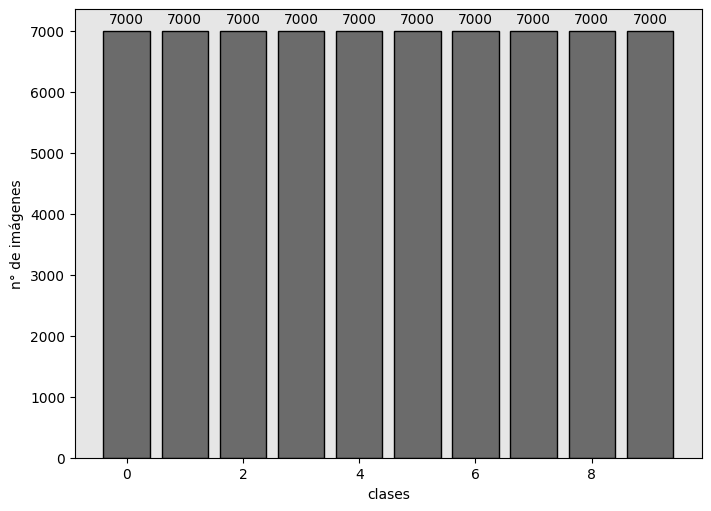

In [ ]:
classes_distribution(
    y,
    figsize=(7,5),
    title='',
    hatch='',
    cmap=None,
    xlabel='clases',
    ylabel='n° de imágenes',
    labelrotation=0,
    facecolor='#e6e6e6',
    color='#6b6b6b'
)

### `Funciones`

In [ ]:
def testing_data(X, Y, samples_per_class):

    '''
    Esta función selecciona un subconjunto balanceado de datos de un conjunto de datos mayor, asegurando que haya un número igual de muestras para cada clase.

    Los datos seleccionados se utilizan para fines de prueba o evaluación, y la función también imprime la forma de los datos resultantes y un gráfico de la distribución de clases.

    Parámetros:
        X: Conjunto de imágenes o datos (ndarray).
        Y: Etiquetas correspondientes a las imágenes o datos (ndarray).
        samples_per_class: Número de muestras a seleccionar por cada clase.

    Retorna:
        X: Subconjunto de datos seleccionados (ndarray).
        Y: Etiquetas correspondientes al subconjunto de datos (ndarray).
    '''

    if samples_per_class > np.max(np.unique(Y, return_counts=True)[1]):
        raise ValueError(f"samples_per_class must be less than {np.max(np.unique(Y, return_counts=True)[1])}")

    for _ in np.unique(Y):
        X = np.delete(X, np.argwhere(Y == _)[samples_per_class:], axis=0)
        Y = np.delete(Y, np.argwhere(Y == _)[samples_per_class:], axis=0)

    print(f"X shape: {X.shape}, Y shape: {Y.shape}")
    classes_distribution(Y, figsize=(7,5), title='', hatch='', cmap=None, xlabel='clases', ylabel='n° de imágenes', labelrotation=0, facecolor='#e6e6e6', color='#6b6b6b')

    return X, Y

In [ ]:
def train_predict(x=None, y=None, classifier=None, classes=None, weights_path=None, write_file=None):

    '''
    Esta función entrena un clasificador ('rfc' o 'mlp') utilizando validación cruzada estratificada con 5 folds
    y evalúa su rendimiento en términos de precisión (accuracy) y F1-score ponderado.

    Los resultados de cada fold y las medias se almacenan en un DataFrame y, opcionalmente, se guardan en un archivo.

    Parámetros:
        x: Vectores de características (ndarray).
        y: Etiquetas (ndarray).
        classifier: Tipo de clasificador a utilizar ('rfc' para RandomForestClassifier o 'mlp' para un perceptrón multicapa).
        classes: Número de clases (requerido para 'mlp').
        weights_path: Ruta para guardar los pesos del modelo 'mlp' (opcional).
        write_file: Ruta para guardar el DataFrame con los resultados (opcional).

    Retorna:
        None. (Los resultados se almacenan en un DataFrame y se guardan en un archivo si se especifica 'write_file'.)

    '''

    if classifier not in ['rfc', 'mlp']:
        raise ValueError("classifier must be 'rfc' or 'mlp'")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    df = pd.DataFrame(columns=['','accuracy', 'f1_weighted'])

    for n, (train_idx, test_idx) in enumerate(skf.split(x, y)):

        if classifier == 'rfc':
            clf = RandomForestClassifier(n_estimators=500, random_state=42)
            clf.fit(x[train_idx], y[train_idx])

            y_pred = clf.predict(x[test_idx])
            accuracy = accuracy_score(y[test_idx], y_pred)
            f1 = f1_score(y[test_idx], y_pred, average='weighted')

            df.loc[len(df)] = ['',accuracy, f1]

        elif classifier == 'mlp':

            dimdin = x.shape[1]

            clf = Sequential()
            clf.add(Dense(256, input_dim=dimdin, activation='relu', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))
            clf.add(BatchNormalization())
            clf.add(Dropout(0.5, seed=1))
            clf.add(Dense(classes, activation='softmax', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))

            optimizer_adam = Adam(learning_rate=0.001)
            SC = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
            MCP = ModelCheckpoint(filepath=weights_path+f"_iteration{n}.keras", save_best_only=True, verbose=0)

            clf.compile(
                optimizer=optimizer_adam,
                loss='categorical_crossentropy',
                metrics=['accuracy', F1Score(average='weighted')]
            )

            fit_hist = clf.fit(
                x=x[train_idx],
                y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[train_idx]),
                epochs=50,
                batch_size=32,
                validation_split=0.2,
                verbose=1,
                callbacks=[SC,MCP],
                shuffle=True
            )

            score = clf.evaluate(x=x[test_idx], y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[test_idx]), verbose=1)

            df.loc[len(df)] = ['', score[1], score[2]]


        del clf

    df.loc[len(df)] = ['means', df['accuracy'].mean(), df['f1_weighted'].mean()]

    #write dataframe
    if write_file != None:
        with open(write_file, 'wb') as file:
            pickle.dump(df, file)

In [ ]:
def cnn_feature_extractor(X, y, extractor=None, weights_path=None, feature_vectors_path=None):

    '''
    Esta función extrae vectores de características de un conjunto de datos utilizando un extractor CNN preentrenado.

    Si el extractor no es entrenable, se utiliza directamente para predecir los vectores de características.
    Si el extractor es entrenable, se realiza una validación cruzada estratificada con 5 folds para encontrar los mejores pesos del modelo,
    y luego se utiliza el extractor con los mejores pesos para predecir los vectores de características.

    Los vectores de características resultantes se guardan en un archivo.

    Parámetros:
        X: Conjunto de imágenes o datos (ndarray).
        y: Etiquetas correspondientes a las imágenes o datos (ndarray).
        extractor: Modelo de extractor CNN (por ejemplo, ResNet50).
        weights_path: Ruta para guardar los pesos del modelo (opcional, solo para extractores entrenables).
        feature_vectors_path: Ruta para guardar los vectores de características extraídos.

    Retorna:
        cnn_feature_vectors: Vectores de características extraídos (ndarray).
    '''

    if extractor.trainable == False:

        cnn_feature_vectors = extractor.predict(X)

    else:

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
        best_weights_dict = {}

        for n, (train_idx, test_idx) in enumerate(skf.split(X, y)):

            weight_path =  weights_path+f"_iteration{n}.keras"

            model = Sequential()
            model.add(extractor)
            model.add(Dense(10, activation='softmax', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))

            optimizer_adam = Adam(learning_rate=0.001)
            SC = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
            MCP = ModelCheckpoint(filepath=weights_path+f"_iteration{n}.keras", save_best_only=True, verbose=0)

            model.compile(
                optimizer=optimizer_adam,
                loss='categorical_crossentropy',
                metrics=['accuracy', F1Score(average='weighted')]
            )

            fit_hist = model.fit(
                x=X[train_idx],
                y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[train_idx]),
                epochs=50,
                batch_size=32,
                validation_split=0.2,
                verbose=1,
                callbacks=[SC, MCP],
                shuffle=True
            )

            score = model.evaluate(x=X[test_idx], y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[test_idx]), verbose=1)
            best_weights_dict[weight_path] = np.mean([score[1], score[2]])

            del model
            del optimizer_adam
            del SC
            del MCP

        model = Sequential()
        model.add(extractor)
        model.add(Dense(10, activation='softmax', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))

        best_weights = max(best_weights_dict, key=best_weights_dict.get)
        model.load_weights(best_weights)
        #model.summary()

        extractor = Model(inputs=extractor.input, outputs=model.layers[-2].output)
        #extractor.summary()
        cnn_feature_vectors = extractor.predict(X)

        del model, extractor

    np.save(feature_vectors_path, cnn_feature_vectors)
    return cnn_feature_vectors

### `Preprocesamiento`

X shape: (5000, 28, 28, 1), Y shape: (5000,)


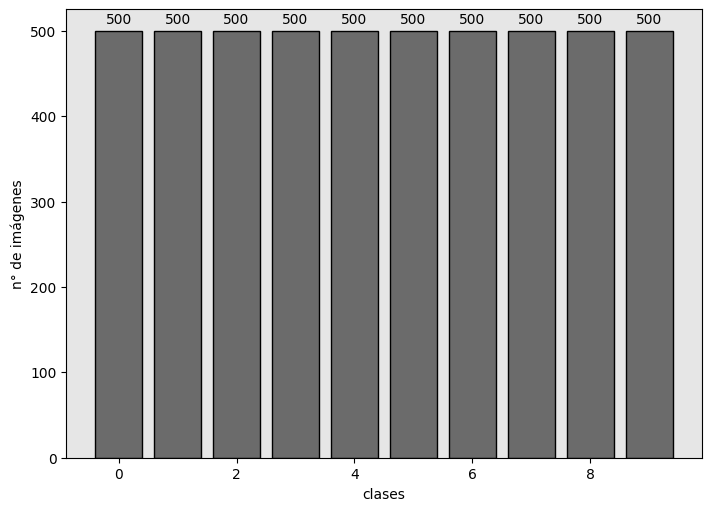

In [ ]:
#selección de un subconjunto de los datos
X, y = testing_data(X, y, samples_per_class=500)

In [ ]:
#gray to rgb
X = np.array([cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) for img in X])
print(f"X shape: {X.shape}, Y shape: {y.shape}")
#redimensionamiento de las imágenes (28, 28) -> (224, 224)
X = np.array([smart_resize(img, (224, 224)) for img in X])
#preprocesamiento para ResNet50
X = resnet50.preprocess_input(X)

print(f"X shape: {X.shape}, Y shape: {y.shape}")

X shape: (5000, 28, 28, 3), Y shape: (5000,)
X shape: (5000, 224, 224, 3), Y shape: (5000,)


### `CNN feature extractor`

In [ ]:
ResNet50NonTrainable = ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=(224, 224, 3),
    pooling='avg',
    classes=10,
    classifier_activation="softmax",
    name="",
)

ResNet50NonTrainable.trainable = False
ResNet50NonTrainable.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: ""

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
start = time.time()
cnn_feature_vectors_ResNet50NonTrainable = cnn_feature_extractor(
    X,
    y,
    extractor=ResNet50NonTrainable,
    weights_path='weights/ResNet50NonTrainable',
    feature_vectors_path='feature_vectors/resnet50nontrainable.npy'
)

print(f"cnn_feature_vectors_ResNet50NonTrainable shape: {cnn_feature_vectors_ResNet50NonTrainable.shape}")
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start} segundos")

157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step
cnn_feature_vectors_ResNet50NonTrainable shape: (5000, 2048)
Tiempo de ejecución: 31.622344493865967 segundos


In [ ]:
ResNet50Trainable = ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=(224, 224, 3),
    pooling='avg',
    classes=10,
    classifier_activation="softmax",
    name="",
)

for layer in ResNet50Trainable.layers[:-37]:
    layer.trainable = False

ResNet50Trainable.summary()

Model: ""

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 15,241,216 (58.14 MB)

 Non-trainable params: 8,346,496 (31.84 MB)

In [ ]:
start_time = time.time()
cnn_feature_vectors_ResNet50Trainable = cnn_feature_extractor(
    X,
    y,
    extractor=ResNet50Trainable,
    weights_path='weights/ResNet50Trainable',
    feature_vectors_path='feature_vectors/resnet50trainable.npy'
)

print(f"cnn_feature_vectors_ResNet50Trainable shape: {cnn_feature_vectors_ResNet50Trainable.shape}")
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time} segundos")

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 205ms/step - accuracy: 0.7353 - f1_score: 0.7341 - loss: 0.9110 - val_accuracy: 0.5688 - val_f1_score: 0.5639 - val_loss: 42.3770
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.9146 - f1_score: 0.9142 - loss: 0.2541 - val_accuracy: 0.6575 - val_f1_score: 0.6504 - val_loss: 4.2787
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 155ms/step - accuracy: 0.9568 - f1_score: 0.9565 - loss: 0.1288 - val_accuracy: 0.8612 - val_f1_score: 0.8613 - val_loss: 0.5240
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.9852 - f1_score: 0.9851 - loss: 0.0664 - val_accuracy: 0.8687 - val_f1_score: 0.8669 - val_loss: 0.5533
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.9729 - f1_score: 0.9729 - loss: 0.0916 - val_accuracy: 0.8413 - val_f1_score: 0.8393 - val_loss: 0.6625
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.9797 - f1_score: 0.9797 - loss: 0.0705 - val_accuracy: 0.8600 - v

### `Clasificación`

#### `MLP NonTrainable`

In [ ]:
train_predict(
    x=cnn_feature_vectors_ResNet50NonTrainable,
    y=y,
    classifier='mlp',
    classes=10,
    weights_path='weights/ResNet50NonTrainable',
    write_file='results/ResNet50NonTrainable.pkl'
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6509 - f1_score: 0.6492 - loss: 1.1645 - val_accuracy: 0.8438 - val_f1_score: 0.8448 - val_loss: 0.5066
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8371 - f1_score: 0.8377 - loss: 0.4709 - val_accuracy: 0.8575 - val_f1_score: 0.8587 - val_loss: 0.4313
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8703 - f1_score: 0.8701 - loss: 0.3664 - val_accuracy: 0.8637 - val_f1_score: 0.8645 - val_loss: 0.3989
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8872 - f1_score: 0.8872 - loss: 0.3178 - val_accuracy: 0.8700 - val_f1_score: 0.8691 - val_loss: 0.3842
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8979 - f1_score: 0.8980 - loss: 0.2853 - val_accuracy: 0.8600 - val_f1_score: 0.8645 - val_loss: 0.3973
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9246 - f1_score: 0.9245 - loss: 0.2321 - val_accuracy: 0.8512 - val_f1_score: 0.8541 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6447 - f1_score: 0.6432 - loss: 1.1234 - val_accuracy: 0.8500 - val_f1_score: 0.8450 - val_loss: 0.4550
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8361 - f1_score: 0.8343 - loss: 0.4793 - val_accuracy: 0.8775 - val_f1_score: 0.8750 - val_loss: 0.3854
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8659 - f1_score: 0.8654 - loss: 0.3819 - val_accuracy: 0.8712 - val_f1_score: 0.8693 - val_loss: 0.3721
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8923 - f1_score: 0.8920 - loss: 0.3246 - val_accuracy: 0.8863 - val_f1_score: 0.8850 - val_loss: 0.3564
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9037 - f1_score: 0.9036 - loss: 0.2791 - val_accuracy: 0.8763 - val_f1_score: 0.8750 - val_loss: 0.3609
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9241 - f1_score: 0.9238 - loss: 0.2400 - val_accuracy: 0.8700 - val_f1_score: 0.8694 - val_los

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6732 - f1_score: 0.6705 - loss: 1.0293 - val_accuracy: 0.7962 - val_f1_score: 0.7828 - val_loss: 0.6548
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8548 - f1_score: 0.8539 - loss: 0.4381 - val_accuracy: 0.8388 - val_f1_score: 0.8328 - val_loss: 0.4546
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8917 - f1_score: 0.8901 - loss: 0.3336 - val_accuracy: 0.8400 - val_f1_score: 0.8265 - val_loss: 0.4870
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9080 - f1_score: 0.9067 - loss: 0.2797 - val_accuracy: 0.8625 - val_f1_score: 0.8594 - val_loss: 0.3897
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9164 - f1_score: 0.9154 - loss: 0.2386 - val_accuracy: 0.8637 - val_f1_score: 0.8630 - val_loss: 0.3839
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9230 - f1_score: 0.9225 - loss: 0.2126 - val_accuracy: 0.8625 - val_f1_score: 0.8595 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6574 - f1_score: 0.6554 - loss: 1.1008 - val_accuracy: 0.8500 - val_f1_score: 0.8498 - val_loss: 0.4745
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8422 - f1_score: 0.8426 - loss: 0.4658 - val_accuracy: 0.8788 - val_f1_score: 0.8782 - val_loss: 0.3609
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8681 - f1_score: 0.8676 - loss: 0.3817 - val_accuracy: 0.8750 - val_f1_score: 0.8752 - val_loss: 0.3382
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8922 - f1_score: 0.8922 - loss: 0.3049 - val_accuracy: 0.8875 - val_f1_score: 0.8883 - val_loss: 0.3104
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9076 - f1_score: 0.9073 - loss: 0.2617 - val_accuracy: 0.8763 - val_f1_score: 0.8764 - val_loss: 0.3354
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9255 - f1_score: 0.9253 - loss: 0.2308 - val_accuracy: 0.8838 - val_f1_score: 0.8848 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6517 - f1_score: 0.6506 - loss: 1.1418 - val_accuracy: 0.8200 - val_f1_score: 0.8132 - val_loss: 0.5872
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8462 - f1_score: 0.8446 - loss: 0.4436 - val_accuracy: 0.8712 - val_f1_score: 0.8672 - val_loss: 0.4177
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8709 - f1_score: 0.8694 - loss: 0.3642 - val_accuracy: 0.8863 - val_f1_score: 0.8826 - val_loss: 0.3786
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8922 - f1_score: 0.8913 - loss: 0.3022 - val_accuracy: 0.8913 - val_f1_score: 0.8888 - val_loss: 0.3226
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9060 - f1_score: 0.9048 - loss: 0.2647 - val_accuracy: 0.8725 - val_f1_score: 0.8662 - val_loss: 0.3693
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9165 - f1_score: 0.9165 - loss: 0.2212 - val_accuracy: 0.8838 - val_f1_score: 0.8792 - val_los

In [ ]:
with open('results/ResNet50NonTrainable.pkl', 'rb') as file:
    df_ResNet50NonTrainable = pickle.load(file)

df_ResNet50NonTrainable

,,accuracy,f1_weighted
0,,0.852,0.851348
1,,0.862,0.859244
2,,0.863,0.861007
3,,0.868,0.866680
4,,0.865,0.864331
5,means,0.862,0.860522


#### `MLP Trainable`

In [ ]:
train_predict(
    x=cnn_feature_vectors_ResNet50Trainable,
    y=y,
    classifier='mlp',
    classes=10,
    weights_path='weights/ResNet50Trainable',
    write_file='results/ResNet50Trainable.pkl'
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9180 - f1_score: 0.9186 - loss: 0.3456 - val_accuracy: 0.9162 - val_f1_score: 0.9163 - val_loss: 0.2849
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0091 - val_accuracy: 0.9187 - val_f1_score: 0.9187 - val_loss: 0.3158
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0038 - val_accuracy: 0.9237 - val_f1_score: 0.9241 - val_loss: 0.3445
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0021 - val_accuracy: 0.9175 - val_f1_score: 0.9176 - val_loss: 0.3520
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0020 - val_accuracy: 0.9150 - val_f1_score: 0.9151 - val_loss: 0.3927
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0011 - val_accuracy: 0.9150 - val_f1_score: 0.9150 - val_loss

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9164 - f1_score: 0.9170 - loss: 0.3272 - val_accuracy: 0.9237 - val_f1_score: 0.9232 - val_loss: 0.3176
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0074 - val_accuracy: 0.9237 - val_f1_score: 0.9237 - val_loss: 0.3403
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - f1_score: 0.9994 - loss: 0.0038 - val_accuracy: 0.9225 - val_f1_score: 0.9221 - val_loss: 0.3802
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0028 - val_accuracy: 0.9225 - val_f1_score: 0.9224 - val_loss: 0.3903
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9999 - f1_score: 0.9999 - loss: 0.0014 - val_accuracy: 0.9175 - val_f1_score: 0.9172 - val_loss: 0.4218
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0018 - val_accuracy: 0.9212 - val_f1_score: 0.9211 - val_loss

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9131 - f1_score: 0.9129 - loss: 0.3696 - val_accuracy: 0.9250 - val_f1_score: 0.9246 - val_loss: 0.2784
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9998 - f1_score: 0.9998 - loss: 0.0081 - val_accuracy: 0.9250 - val_f1_score: 0.9247 - val_loss: 0.3151
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9990 - f1_score: 0.9990 - loss: 0.0060 - val_accuracy: 0.9262 - val_f1_score: 0.9261 - val_loss: 0.3235
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0024 - val_accuracy: 0.9312 - val_f1_score: 0.9310 - val_loss: 0.3396
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0017 - val_accuracy: 0.9300 - val_f1_score: 0.9297 - val_loss: 0.3624
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0016 - val_accuracy: 0.9275 - val_f1_score: 0.9274 - val_loss

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9186 - f1_score: 0.9187 - loss: 0.3207 - val_accuracy: 0.9225 - val_f1_score: 0.9224 - val_loss: 0.2889
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9989 - f1_score: 0.9989 - loss: 0.0115 - val_accuracy: 0.9250 - val_f1_score: 0.9254 - val_loss: 0.3097
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9997 - f1_score: 0.9997 - loss: 0.0053 - val_accuracy: 0.9262 - val_f1_score: 0.9264 - val_loss: 0.3229
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9998 - f1_score: 0.9998 - loss: 0.0025 - val_accuracy: 0.9200 - val_f1_score: 0.9201 - val_loss: 0.3669
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0015 - val_accuracy: 0.9175 - val_f1_score: 0.9177 - val_loss: 0.3694
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - f1_score: 0.9994 - loss: 0.0022 - val_accuracy: 0.9262 - val_f1_score: 0.9265 - val_loss

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9200 - f1_score: 0.9206 - loss: 0.3432 - val_accuracy: 0.9250 - val_f1_score: 0.9245 - val_loss: 0.2675
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9996 - f1_score: 0.9996 - loss: 0.0065 - val_accuracy: 0.9225 - val_f1_score: 0.9220 - val_loss: 0.3092
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0028 - val_accuracy: 0.9212 - val_f1_score: 0.9208 - val_loss: 0.3336
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0014 - val_accuracy: 0.9262 - val_f1_score: 0.9260 - val_loss: 0.3345
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0011 - val_accuracy: 0.9275 - val_f1_score: 0.9274 - val_loss: 0.3509
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 6.5832e-04 - val_accuracy: 0.9262 - val_f1_score: 0.9259 - val_

In [ ]:
with open('results/ResNet50Trainable.pkl', 'rb') as file:
    df_ResNet50Trainable = pickle.load(file)

df_ResNet50Trainable

,,accuracy,f1_weighted
0,,0.9850,0.984941
1,,0.9840,0.984009
2,,0.9830,0.983000
3,,0.9840,0.983953
4,,0.9810,0.981035
5,means,0.9834,0.983388


#### `RFC NonTrainable`

In [ ]:
train_predict(
    x=cnn_feature_vectors_ResNet50NonTrainable,
    y=y,
    classifier='rfc',
    classes=None,
    weights_path=None,
    write_file='results/ResNet50NonTrainableRFC.pkl'
)

In [ ]:
with open('results/ResNet50NonTrainableRFC.pkl', 'rb') as file:
    df_ResNet50NonTrainableRFC = pickle.load(file)

df_ResNet50NonTrainableRFC

,,accuracy,f1_weighted
0,,0.8500,0.846036
1,,0.8550,0.853233
2,,0.8310,0.828838
3,,0.8650,0.862797
4,,0.8570,0.853700
5,means,0.8516,0.848921


#### `RFC Trainable`

In [ ]:
train_predict(
    x=cnn_feature_vectors_ResNet50Trainable,
    y=y,
    classifier='rfc',
    classes=None,
    weights_path=None,
    write_file='results/ResNet50TrainableRFC.pkl'
)

In [ ]:
with open('results/ResNet50TrainableRFC.pkl', 'rb') as file:
    df_ResNet50TrainableRFC = pickle.load(file)

df_ResNet50TrainableRFC

,,accuracy,f1_weighted
0,,0.9840,0.983975
1,,0.9840,0.984014
2,,0.9810,0.980948
3,,0.9820,0.981979
4,,0.9810,0.981049
5,means,0.9824,0.982393
